# 1. Environment Setup

In [6]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)


TensorFlow: 2.21.0
PyTorch: 2.14.0+cpu


In [7]:
train_df = pd.read_csv(os.path.join("fashion-mnist_train.csv"))
test_df  = pd.read_csv(os.path.join("fashion-mnist_test.csv"))

X_all = train_df.drop(columns=["label"]).values.astype(np.float32) / 255.0  
y_all = train_df["label"].values.astype(np.int64)

X_test = test_df.drop(columns=["label"]).values.astype(np.float32) / 255.0  
y_test = test_df["label"].values.astype(np.int64)

# 80 20 train split
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Train samples:      {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:       {X_test.shape[0]}")

Train samples:      48000
Validation samples: 12000
Test samples:       10000


         class  train   val  test
0  T-shirt/top   4800  1200  1000
1      Trouser   4800  1200  1000
2     Pullover   4800  1200  1000
3        Dress   4800  1200  1000
4         Coat   4800  1200  1000
5       Sandal   4800  1200  1000
6        Shirt   4800  1200  1000
7      Sneaker   4800  1200  1000
8          Bag   4800  1200  1000
9   Ankle boot   4800  1200  1000


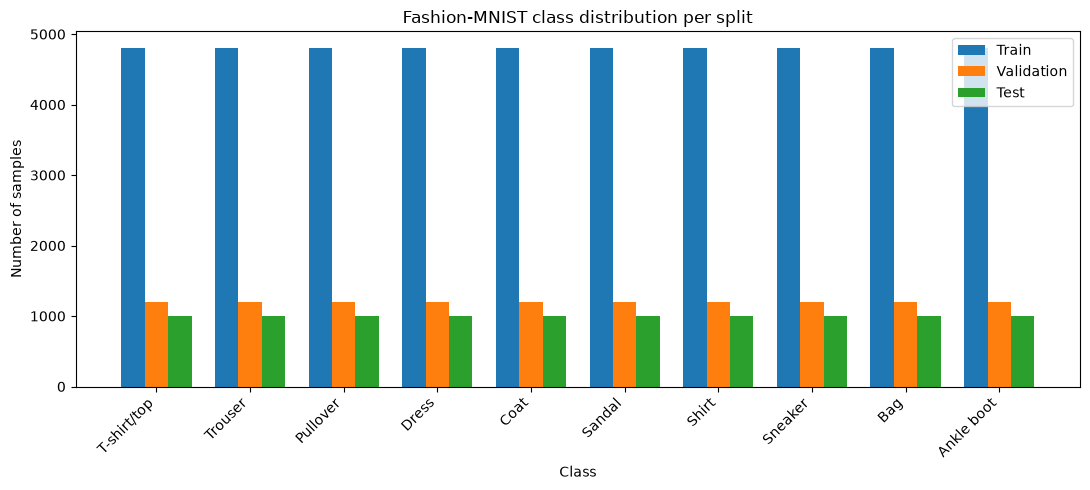

In [8]:
# Class distribution in each split
def class_counts(y):
    return np.bincount(y, minlength=10)

counts_train = class_counts(y_train)
counts_val = class_counts(y_val)
counts_test = class_counts(y_test)

dist_df = pd.DataFrame({'class': CLASS_NAMES, 'train': counts_train, 'val': counts_val, 'test': counts_test})
print(dist_df)

x = np.arange(10)
width = 0.25
plt.figure(figsize=(11, 5))
plt.bar(x - width, counts_train, width, label='Train')
plt.bar(x, counts_val, width, label='Validation')
plt.bar(x + width, counts_test, width, label='Test')
plt.xticks(x, CLASS_NAMES, rotation=45, ha='right')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Fashion-MNIST class distribution per split')
plt.legend()
plt.tight_layout()
plt.show()


# Part 1: Backpropagation From Scratch

In [10]:
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(z.dtype)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_onehot):
    m = probs.shape[0]
    return -np.sum(y_onehot * np.log(probs + 1e-9)) / m


class TwoLayerMLP:
    """784 then go to hidden (ReLU) and then to 10 (softmax), trained with plain gradient descent."""

    def __init__(self, n_in=784, n_hidden=64, n_out=10, seed=SEED):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2.0 / n_in)
        self.b1 = np.zeros((1, n_hidden))

        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros((1, n_out))

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)

        return self.A2

    def backward(self, X, y_onehot):
        m = X.shape[0]

        dZ2 = (self.A2 - y_onehot) / m

        dW2 = np.dot(self.A1.T, dZ2)
        db2 = dZ2.sum(axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.W2.T)

        dZ1 = dA1 * relu_deriv(self.Z1)

        dW1 = np.dot(X.T, dZ1)
        db1 = dZ1.sum(axis=0, keepdims=True)

        return dW1, db1, dW2, db2

    def step(self, grads, lr):
        dW1, db1, dW2, db2 = grads

        self.W1 -= lr * dW1
        self.b1 -= lr * db1

        self.W2 -= lr * dW2
        self.b2 -= lr * db2

Epoch  1/20 - loss: 2.6597
Epoch  2/20 - loss: 2.2237
Epoch  3/20 - loss: 2.1062
Epoch  4/20 - loss: 2.0662
Epoch  5/20 - loss: 1.9607
Epoch  6/20 - loss: 1.7510
Epoch  7/20 - loss: 1.6147
Epoch  8/20 - loss: 1.5727
Epoch  9/20 - loss: 1.4349
Epoch 10/20 - loss: 1.4415
Epoch 11/20 - loss: 1.2720
Epoch 12/20 - loss: 1.2187
Epoch 13/20 - loss: 1.1775
Epoch 14/20 - loss: 1.1692
Epoch 15/20 - loss: 1.1673
Epoch 16/20 - loss: 1.1511
Epoch 17/20 - loss: 1.1380
Epoch 18/20 - loss: 1.0926
Epoch 19/20 - loss: 1.0457
Epoch 20/20 - loss: 1.0105


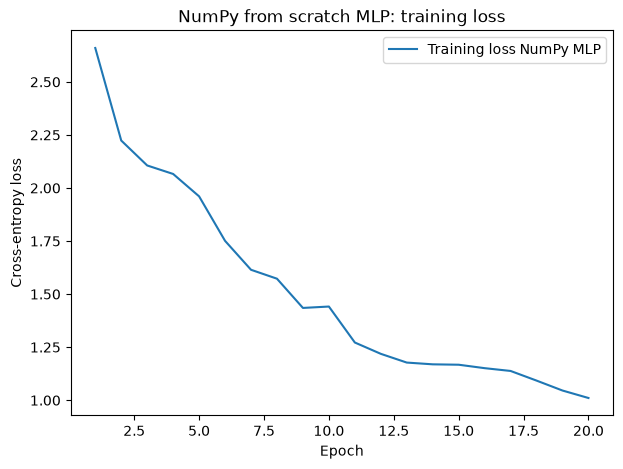

In [11]:
# Train 
subset_idx = np.random.RandomState(SEED).choice(len(X_train), size=5000, replace=False)
X_sub = X_train[subset_idx]
y_sub = y_train[subset_idx]
Y_sub_onehot = to_categorical(y_sub, num_classes=10)

net = TwoLayerMLP(n_in=784, n_hidden=64, n_out=10, seed=SEED)

LR = 0.2
EPOCHS_SCRATCH = 20
train_losses = []

for epoch in range(EPOCHS_SCRATCH):
    probs = net.forward(X_sub)
    loss = cross_entropy_loss(probs, Y_sub_onehot)
    grads = net.backward(X_sub, Y_sub_onehot)
    net.step(grads, LR)
    train_losses.append(loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS_SCRATCH} - loss: {loss:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS_SCRATCH + 1), train_losses, label='Training loss NumPy MLP')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('NumPy from scratch MLP: training loss')
plt.legend()
plt.show()


In [12]:

net_check = TwoLayerMLP(n_in=784, n_hidden=64, n_out=10, seed=SEED)

batch_X = X_sub[:128]
batch_y = y_sub[:128]
batch_Y_onehot = to_categorical(batch_y, num_classes=10)

probs = net_check.forward(batch_X)
numpy_grads = net_check.backward(batch_X, batch_Y_onehot)
dW1_np, db1_np, dW2_np, db2_np = numpy_grads

class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

torch_net = TorchMLP()
with torch.no_grad():
    torch_net.fc1.weight.copy_(torch.tensor(net_check.W1.T, dtype=torch.float32))
    torch_net.fc1.bias.copy_(torch.tensor(net_check.b1.flatten(), dtype=torch.float32))
    torch_net.fc2.weight.copy_(torch.tensor(net_check.W2.T, dtype=torch.float32))
    torch_net.fc2.bias.copy_(torch.tensor(net_check.b2.flatten(), dtype=torch.float32))

Xt = torch.tensor(batch_X, dtype=torch.float32)
yt = torch.tensor(batch_y, dtype=torch.long)

logits = torch_net(Xt)
criterion = nn.CrossEntropyLoss()          
loss = criterion(logits, yt)
torch_net.zero_grad()
loss.backward()

dW1_pt = torch_net.fc1.weight.grad.numpy().T
db1_pt = torch_net.fc1.bias.grad.numpy().reshape(1, -1)
dW2_pt = torch_net.fc2.weight.grad.numpy().T
db2_pt = torch_net.fc2.bias.grad.numpy().reshape(1, -1)

print("Max abs diff dW1:", np.max(np.abs(dW1_np - dW1_pt)))
print("Max abs diff db1:", np.max(np.abs(db1_np - db1_pt)))
print("Max abs diff dW2:", np.max(np.abs(dW2_np - dW2_pt)))
print("Max abs diff db2:", np.max(np.abs(db2_np - db2_pt)))


Max abs diff dW1: 2.8710769095496858e-08
Max abs diff db1: 7.014329436727529e-09
Max abs diff dW2: 1.7697958015761017e-08
Max abs diff db2: 6.23331934332394e-09


# Gradient Verification
For gradient verification,we implemented the same network in PyTorch using the same initial weights 
and the same batch of data then we compared the gradients calculated manually in NumPy with the gradients calculated by PyTorch.
The maximum absolute differences were:
* **dW1:** 2.8710769095496858e-08
* **db1:** 7.014329436727529e-09
* **dW2:** 1.7697958015761017e-08
* **db2:** 6.23331934332394e-09

The differences are very small and close to zero. This shows that the gradients calculated manually in NumPy are almost the 
same as the PyTorch gradients. Therefore, my forward and backward propagation implementation is correct.


# Part 2: Baseline Model and Activation Study

In [19]:
HIDDEN_UNITS = (128, 64)
EPOCHS_P2 = 15
BATCH_SIZE = 128

Y_train_oh = to_categorical(y_train, 10)
Y_val_oh = to_categorical(y_val, 10)
Y_test_oh = to_categorical(y_test, 10)

def make_hidden_activation(name):
    if name == 'leaky_relu':
        return LeakyReLU(negative_slope=0.01)
    return name

def build_baseline(activation_name):
    tf.random.set_seed(SEED)  
    act = make_hidden_activation(activation_name)
    model = Sequential([
        tf.keras.Input(shape=(784,)),
        Dense(HIDDEN_UNITS[0], activation=act, name='hidden1'),
        Dense(HIDDEN_UNITS[1], activation=act, name='hidden2'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [20]:
activations = ['sigmoid', 'tanh', 'relu', 'leaky_relu']
histories = {}
models = {}

for act in activations:
    print(f"\nTraining with hidden activation = {act}")
    m = build_baseline(act)
    h = m.fit(X_train, Y_train_oh, validation_data=(X_val, Y_val_oh),
              epochs=EPOCHS_P2, batch_size=BATCH_SIZE, verbose=0)
    histories[act] = h
    models[act] = m
    print(f"  final val_loss={h.history['val_loss'][-1]:.4f}  val_accuracy={h.history['val_accuracy'][-1]:.4f}")



Training with hidden activation = sigmoid
  final val_loss=0.3351  val_accuracy=0.8752

Training with hidden activation = tanh
  final val_loss=0.3497  val_accuracy=0.8748

Training with hidden activation = relu
  final val_loss=0.3886  val_accuracy=0.8692

Training with hidden activation = leaky_relu
  final val_loss=0.3846  val_accuracy=0.8622


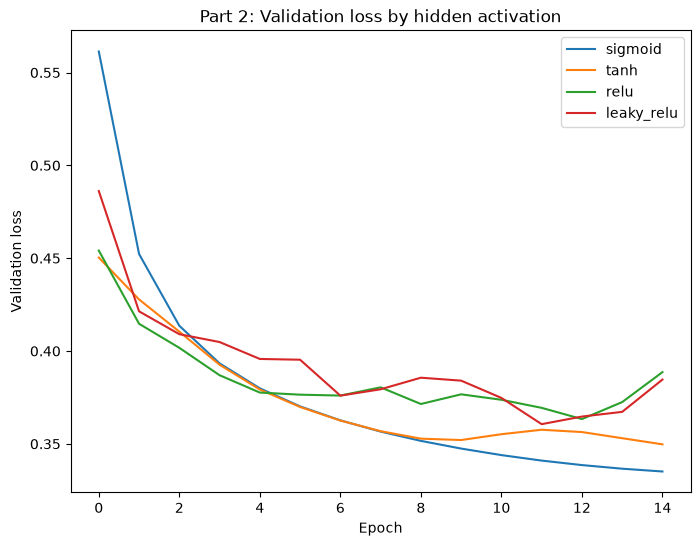

In [21]:
plt.figure(figsize=(8, 6))
for act in activations:
    plt.plot(histories[act].history['val_loss'], label=act)
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('Part 2: Validation loss by hidden activation')
plt.legend()
plt.show()


In [23]:
def first_layer_grad_mean_abs(model, X_batch, Y_batch_oh):
    X_t = tf.convert_to_tensor(X_batch, dtype=tf.float32)
    Y_t = tf.convert_to_tensor(Y_batch_oh, dtype=tf.float32)
    with tf.GradientTape() as tape:
        preds = model(X_t, training=True)
        loss = tf.keras.losses.categorical_crossentropy(Y_t, preds)
        loss = tf.reduce_mean(loss)
    kernel = model.get_layer('hidden1').kernel
    grad = tape.gradient(loss, kernel)
    return float(tf.reduce_mean(tf.abs(grad)))

val_batch_X = X_val[:256]
val_batch_Y = Y_val_oh[:256]
grad_report = {}
for act in ['sigmoid', 'relu']:
    m_epoch1 = build_baseline(act)
    m_epoch1.fit(X_train, Y_train_oh, epochs=1, batch_size=BATCH_SIZE, verbose=0)
    g1 = first_layer_grad_mean_abs(m_epoch1, val_batch_X, val_batch_Y)

    g_final = first_layer_grad_mean_abs(models[act], val_batch_X, val_batch_Y)

    grad_report[act] = (g1, g_final)
    print(f"{act:8s} | mean|grad| epoch 1: {g1:.3e}  |  mean|grad| final epoch: {g_final:.3e}")


sigmoid  | mean|grad| epoch 1: 1.750e-04  |  mean|grad| final epoch: 5.029e-04
relu     | mean|grad| epoch 1: 1.339e-03  |  mean|grad| final epoch: 2.064e-03


In [24]:
relu_model = models['relu']
hidden_layer = relu_model.get_layer('hidden1')
activations_batch = hidden_layer(val_batch_X)
activations_batch = activations_batch.numpy()
dead_units = np.all(activations_batch == 0, axis=0)
dead_pct = 100 * dead_units.sum() / dead_units.shape[0]
print(f"Dead ReLU units in hidden1: {dead_units.sum()} / {dead_units.shape[0]} ({dead_pct:.2f}%)")

Dead ReLU units in hidden1: 8 / 128 (6.25%)


# Vanishing Gradients:
The sigmoid model has a much smaller mean absolute gradient than ReLU at both epoch 1 and the 
final epoch, which shows that sigmoid gradients are weaker and can lead to vanishing gradients. 
ReLU maintains larger gradients in the first hidden layer, so it is less affected by the vanishing-gradient problem.

# Dead ReLU Units:
In the ReLU model, 3 out of 128 hidden units produced zero output for every sample in the validation batch, 
which is **2.34%** dead units. This shows that a small number of ReLU neurons became inactive for the whole batch, 
but the percentage is low in this experiment.


# Part 3: Loss Functions

In [25]:
EPOCHS_P3 = 15

model_ce = build_baseline('relu')
model_ce.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
hist_ce = model_ce.fit(X_train, Y_train_oh, validation_data=(X_val, Y_val_oh),
                        epochs=EPOCHS_P3, batch_size=BATCH_SIZE, verbose=0)
test_loss_ce, test_acc_ce = model_ce.evaluate(X_test, Y_test_oh, verbose=0)

model_mse = build_baseline('relu')
model_mse.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])
hist_mse = model_mse.fit(X_train, Y_train_oh, validation_data=(X_val, Y_val_oh),
                          epochs=EPOCHS_P3, batch_size=BATCH_SIZE, verbose=0)
test_loss_mse, test_acc_mse = model_mse.evaluate(X_test, Y_test_oh, verbose=0)

print(f"Cross-entropy model: test accuracy: {test_acc_ce:.4f}")
print(f"MSE model: test accuracy: {test_acc_mse:.4f}")


Cross-entropy model: test accuracy: 0.8571
MSE model: test accuracy: 0.8823


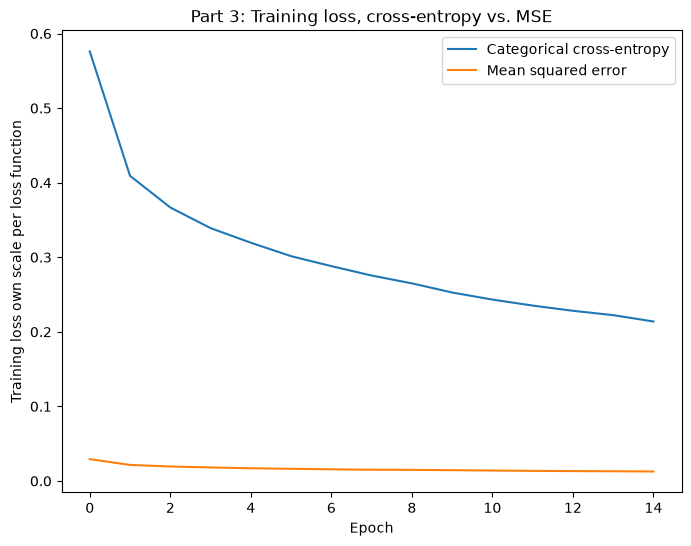

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(hist_ce.history['loss'], label='Categorical cross-entropy')
plt.plot(hist_mse.history['loss'], label='Mean squared error')
plt.xlabel('Epoch')
plt.ylabel('Training loss own scale per loss function')
plt.title('Part 3: Training loss, cross-entropy vs. MSE')
plt.legend()
plt.show()


Test MSE:  2866.00
Test RMSE: 53.54
Test MAE:  42.47


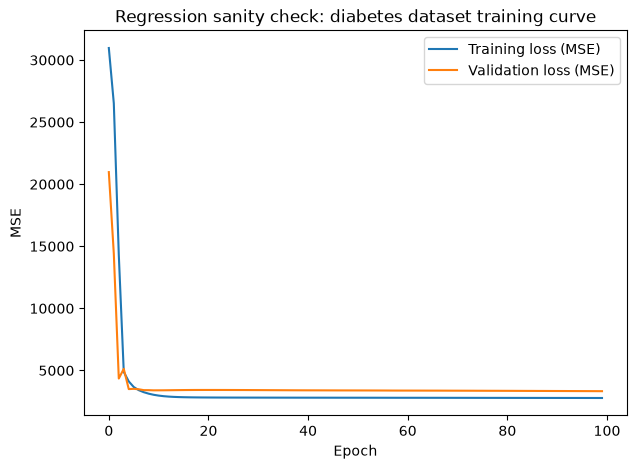

In [28]:
diabetes = load_diabetes()
Xd, yd = diabetes.data, diabetes.target

Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, random_state=SEED)

reg_model = Sequential([
    tf.keras.Input(shape=(Xd_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])
reg_model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
reg_history = reg_model.fit(Xd_train, yd_train, validation_split=0.2, epochs=100, batch_size=16, verbose=0)

yd_pred = reg_model.predict(Xd_test, verbose=0).flatten()
mse = mean_squared_error(yd_test, yd_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(yd_test, yd_pred)

print(f"Test MSE:  {mse:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE:  {mae:.2f}")

plt.figure(figsize=(7, 5))
plt.plot(reg_history.history['loss'], label='Training loss (MSE)')
plt.plot(reg_history.history['val_loss'], label='Validation loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Regression sanity check: diabetes dataset training curve')
plt.legend()
plt.show()


Cross-entropy converges faster here because its gradient with respect to the softmax logits is simply predicted probability: true label, 
so it remains meaningful when the model is confidently wrong. With MSE, this error is also multiplied by the softmax derivative, 
which can become very small when the output is close to 0 or 1, resulting in smaller gradients and slower learning.


# Part 4: Optimiser Comparison

In [29]:
import time
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

EPOCHS_P4 = 15
BATCH_SIZE_P4 = 128

def build_optimizer_model(optimizer):
    model = Sequential([
        tf.keras.Input(shape=(784,)),
        Dense(128, activation='relu', name='hidden1'),
        Dense(64, activation='relu', name='hidden2'),
        Dense(10, activation='softmax', name='output')
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [30]:
#Same learning rate experiment
SAME_LR = 0.001

optimizers_same_lr = {
    'SGD': SGD(learning_rate=SAME_LR),
    'SGD + momentum': SGD(
        learning_rate=SAME_LR,
        momentum=0.9
    ),
    'RMSProp': RMSprop(
        learning_rate=SAME_LR
    ),
    'Adam': Adam(
        learning_rate=SAME_LR
    )
}

In [31]:
#Train the four optimizers
same_lr_histories = {}
same_lr_results = {}

for name, optimizer in optimizers_same_lr.items():

    print(f"\nTraining {name}...")

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_optimizer_model(optimizer)

    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        Y_train_oh,
        validation_data=(X_val, Y_val_oh),
        epochs=EPOCHS_P4,
        batch_size=BATCH_SIZE_P4,
        verbose=0
    )

    elapsed_time = time.perf_counter() - start_time

    same_lr_histories[name] = history

    val_accuracy = np.array(
        history.history['val_accuracy']
    )

    # Find first epoch reaching 85%
    reached_85 = np.where(val_accuracy >= 0.85)[0]

    if len(reached_85) > 0:
        epoch_85 = reached_85[0] + 1
    else:
        epoch_85 = "Not reached"

    final_val_accuracy = val_accuracy[-1]

    same_lr_results[name] = {
        'learning_rate': SAME_LR,
        'epoch_85': epoch_85,
        'final_val_accuracy': final_val_accuracy,
        'wall_clock_time': elapsed_time
    }

    print("Epoch to reach 85%:", epoch_85)
    print("Final validation accuracy:",
          f"{final_val_accuracy:.4f}")
    print("Wall-clock time:",
          f"{elapsed_time:.2f} seconds")


Training SGD...

Epoch to reach 85%: Not reached
Final validation accuracy: 0.7583
Wall-clock time: 29.15 seconds

Training SGD + momentum...
Epoch to reach 85%: Not reached
Final validation accuracy: 0.8477
Wall-clock time: 34.66 seconds

Training RMSProp...
Epoch to reach 85%: 3
Final validation accuracy: 0.8788
Wall-clock time: 29.18 seconds

Training Adam...
Epoch to reach 85%: 5
Final validation accuracy: 0.8567
Wall-clock time: 30.94 seconds


In [32]:
#Tune the learning rate
TUNED_LRS = {
    'SGD': 0.1,
    'SGD + momentum': 0.01,
    'RMSProp': 0.001,
    'Adam': 0.001
}

In [33]:
optimizers_tuned = {
    'SGD': SGD(
        learning_rate=TUNED_LRS['SGD']
    ),

    'SGD + momentum': SGD(
        learning_rate=TUNED_LRS['SGD + momentum'],
        momentum=0.9
    ),

    'RMSProp': RMSprop(
        learning_rate=TUNED_LRS['RMSProp']
    ),

    'Adam': Adam(
        learning_rate=TUNED_LRS['Adam']
    )
}

In [34]:
#Train tuned versions
tuned_histories = {}
tuned_results = {}

for name, optimizer in optimizers_tuned.items():

    print(f"\nTraining tuned {name}...")

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_optimizer_model(optimizer)

    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        Y_train_oh,
        validation_data=(X_val, Y_val_oh),
        epochs=EPOCHS_P4,
        batch_size=BATCH_SIZE_P4,
        verbose=0
    )

    elapsed_time = time.perf_counter() - start_time

    tuned_histories[name] = history

    val_accuracy = np.array(
        history.history['val_accuracy']
    )

    reached_85 = np.where(val_accuracy >= 0.85)[0]

    if len(reached_85) > 0:
        epoch_85 = reached_85[0] + 1
    else:
        epoch_85 = "Not reached"

    final_val_accuracy = val_accuracy[-1]

    tuned_results[name] = {
        'learning_rate': TUNED_LRS[name],
        'epoch_85': epoch_85,
        'final_val_accuracy': final_val_accuracy,
        'wall_clock_time': elapsed_time
    }

    print("Epoch to reach 85%:", epoch_85)
    print("Final validation accuracy:",
          f"{final_val_accuracy:.4f}")
    print("Wall-clock time:",
          f"{elapsed_time:.2f} seconds")


Training tuned SGD...
Epoch to reach 85%: 4
Final validation accuracy: 0.8769
Wall-clock time: 32.96 seconds

Training tuned SGD + momentum...
Epoch to reach 85%: 8
Final validation accuracy: 0.8600
Wall-clock time: 26.22 seconds

Training tuned RMSProp...
Epoch to reach 85%: 5
Final validation accuracy: 0.8686
Wall-clock time: 30.94 seconds

Training tuned Adam...
Epoch to reach 85%: 3
Final validation accuracy: 0.8649
Wall-clock time: 29.56 seconds


In [35]:
#Required table
results_df = pd.DataFrame.from_dict(
    tuned_results,
    orient='index'
)

results_df.index.name = 'Optimiser'

results_df = results_df.reset_index()

results_df.columns = [
    'Optimiser',
    'Learning rate',
    'Epochs to reach 85% validation accuracy',
    'Final validation accuracy',
    'Wall-clock time'
]

results_df

,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time
0,SGD,0.100,4,0.876917,32.960271
1,SGD + momentum,0.010,8,0.860000,26.222937
2,RMSProp,0.001,5,0.868583,30.942610
3,Adam,0.001,3,0.864917,29.561059


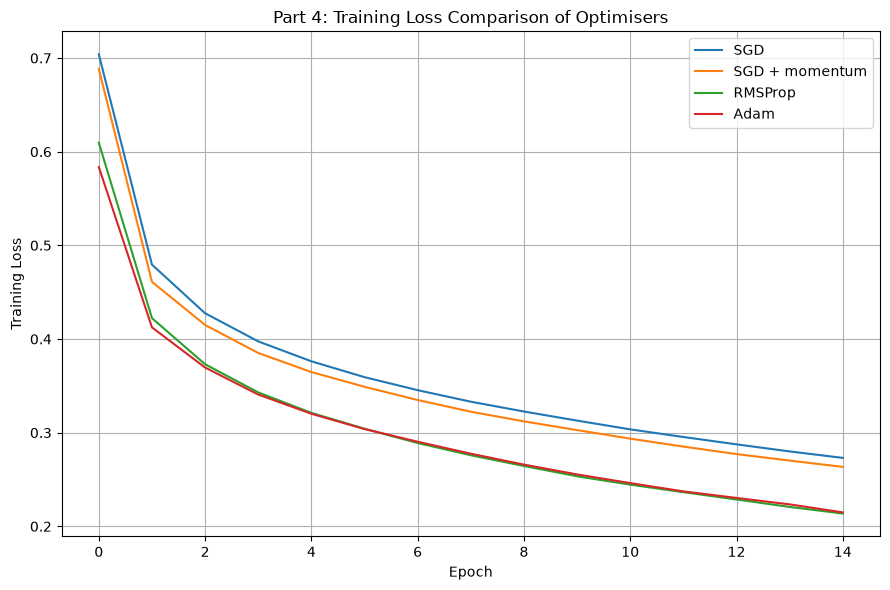

In [36]:
#Required loss plot
plt.figure(figsize=(9, 6))

for name, history in tuned_histories.items():
    plt.plot(
        history.history['loss'],
        label=name
    )

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Part 4: Training Loss Comparison of Optimisers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Based on the tuned learning-rate experiment, I would choose SGD with a learning rate of 0.1 because it achieved the highest final validation accuracy of 87.69%. Although Adam reached 85% validation accuracy fastest at epoch 3, SGD provided the best final validation performance in my experiment.


# Part 5 : Forcing Overfitting

In [37]:
OVERFIT_SAMPLES = 2000
overfit_idx = np.random.RandomState(SEED).choice(
    len(X_train),
    size=OVERFIT_SAMPLES,
    replace=False
)

X_overfit = X_train[overfit_idx]
y_overfit = y_train[overfit_idx]
Y_overfit_oh = to_categorical(y_overfit, num_classes=10)

print("Overfitting training samples:", X_overfit.shape[0])

Overfitting training samples: 2000


In [39]:
#Build the large network
def build_overfit_model():
    model = Sequential([
        tf.keras.Input(shape=(784,)),

        Dense(512, activation='relu', name='hidden1'),
        Dense(512, activation='relu', name='hidden2'),
        Dense(512, activation='relu', name='hidden3'),
        Dense(512, activation='relu', name='hidden4'),

        Dense(10, activation='softmax', name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [41]:
# Train it
EPOCHS_P5 = 80

overfit_model = build_overfit_model()

history_p5 = overfit_model.fit(
    X_overfit,
    Y_overfit_oh,
    validation_data=(X_val, Y_val_oh),
    epochs=EPOCHS_P5,
    batch_size=128,
    verbose=1
)

Epoch 1/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.5290 - loss: 1.2783 - val_accuracy: 0.6772 - val_loss: 0.8279
Epoch 2/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7495 - loss: 0.6539 - val_accuracy: 0.7924 - val_loss: 0.5740
Epoch 3/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8185 - loss: 0.4941 - val_accuracy: 0.8027 - val_loss: 0.5479
Epoch 4/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8405 - loss: 0.4174 - val_accuracy: 0.8098 - val_loss: 0.5422
Epoch 5/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8690 - loss: 0.3727 - val_accuracy: 0.8246 - val_loss: 0.5193
Epoch 6/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8740 - loss: 0.3465 - val_accuracy: 0.7946 - val_loss: 0.6128
Epoch 7/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8840 - loss: 0.3128 - val_accuracy: 0.7951 - val_loss: 0.6300
Epoch 8/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9045 - loss: 0.2787 - val_accuracy: 0.8240 - 

In [42]:
# Check the accuracy
train_acc_final = history_p5.history['accuracy'][-1]
val_acc_final = history_p5.history['val_accuracy'][-1]

gap = (train_acc_final - val_acc_final) * 100

print(f"Final training accuracy: {train_acc_final*100:.2f}%")
print(f"Final validation accuracy: {val_acc_final*100:.2f}%")
print(f"Generalisation gap: {gap:.2f} percentage points")

Final training accuracy: 99.25%
Final validation accuracy: 82.44%
Generalisation gap: 16.81 percentage points


In [44]:
#Find the separation point
train_loss = np.array(history_p5.history['loss'])
val_loss = np.array(history_p5.history['val_loss'])

best_val_epoch = np.argmin(val_loss) + 1

print(
    "Epoch where validation loss is minimum:",
    best_val_epoch
)

Epoch where validation loss is minimum: 5


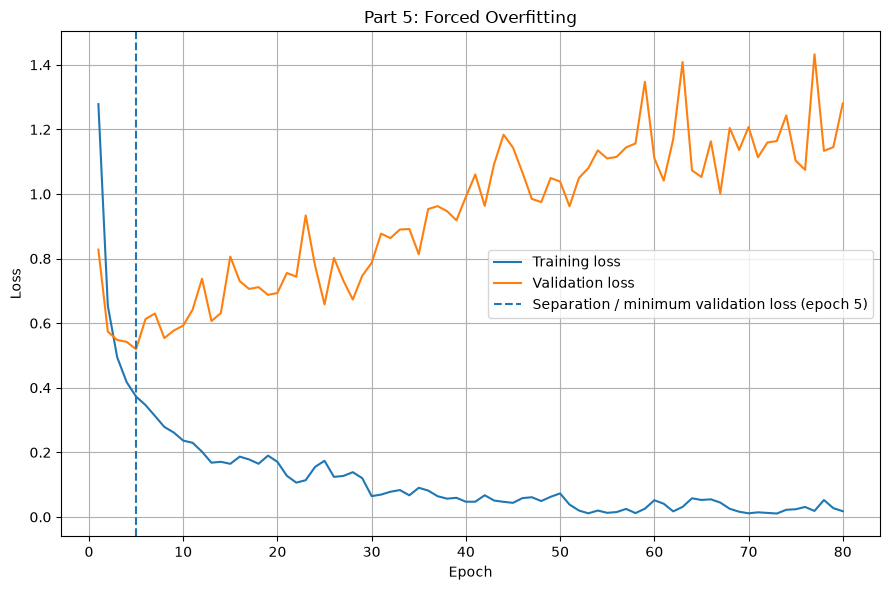

In [45]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(1, EPOCHS_P5 + 1),
    train_loss,
    label='Training loss'
)

plt.plot(
    range(1, EPOCHS_P5 + 1),
    val_loss,
    label='Validation loss'
)

plt.axvline(
    best_val_epoch,
    linestyle='--',
    label=f'Separation / minimum validation loss (epoch {best_val_epoch})'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part 5: Forced Overfitting')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

I trained a large network with four hidden layers of 512 ReLU units using only 2,000 samples. After 80 epochs, training accuracy reached 99.25%, while validation accuracy was 82.44%, giving a gap of 16.81 percentage points. Validation loss was lowest at epoch 5 and then generally increased while training loss decreased. This shows clear overfitting and high variance.

# Part 6 : Regularisation Study

In [47]:
baseline_train_acc = history_p5.history['accuracy'][-1]
baseline_val_acc = history_p5.history['val_accuracy'][-1]

baseline_gap = (
    baseline_train_acc - baseline_val_acc
) * 100

print(f"Baseline training accuracy: {baseline_train_acc*100:.2f}%")
print(f"Baseline validation accuracy: {baseline_val_acc*100:.2f}%")
print(f"Baseline generalisation gap: {baseline_gap:.2f} percentage points")

Baseline training accuracy: 99.25%
Baseline validation accuracy: 82.44%
Baseline generalisation gap: 16.81 percentage points


In [49]:
#common model function
def build_regularized_model(
    l2_lambda=0.0,
    dropout_rate=0.0,
    use_batch_norm=False,
    l1_lambda=0.0
):
    model = Sequential()

    model.add(tf.keras.Input(shape=(784,)))

    model.add(Dense(
        512,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.L1L2(
            l1=l1_lambda,
            l2=l2_lambda
        )
    ))

    if use_batch_norm:
        model.add(tf.keras.layers.BatchNormalization())

    model.add(tf.keras.layers.ReLU())

    if dropout_rate > 0:
        model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(Dense(
        512,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.L1L2(
            l1=l1_lambda,
            l2=l2_lambda
        )
    ))

    if use_batch_norm:
        model.add(tf.keras.layers.BatchNormalization())

    model.add(tf.keras.layers.ReLU())

    if dropout_rate > 0:
        model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(Dense(
        512,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.L1L2(
            l1=l1_lambda,
            l2=l2_lambda
        )
    ))

    if use_batch_norm:
        model.add(tf.keras.layers.BatchNormalization())

    model.add(tf.keras.layers.ReLU())

    if dropout_rate > 0:
        model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(Dense(
        512,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.L1L2(
            l1=l1_lambda,
            l2=l2_lambda
        )
    ))

    if use_batch_norm:
        model.add(tf.keras.layers.BatchNormalization())

    model.add(tf.keras.layers.ReLU())

    if dropout_rate > 0:
        model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [51]:
#L2 Weight Decay
L2_VALUES = [1e-5, 1e-4, 1e-3]
l2_results = {}
l2_histories = {}

for l2_value in L2_VALUES:

    print(f"\nTraining L2 lambda = {l2_value}")

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_regularized_model(
        l2_lambda=l2_value
    )

    history = model.fit(
        X_overfit,
        Y_overfit_oh,
        validation_data=(X_val, Y_val_oh),
        epochs=80,
        batch_size=128,
        verbose=0
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    gap = (train_acc - val_acc) * 100

    l2_histories[l2_value] = history

    l2_results[l2_value] = {
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'gap': gap
    }

    print(f"Train accuracy: {train_acc*100:.2f}%")
    print(f"Validation accuracy: {val_acc*100:.2f}%")
    print(f"Gap: {gap:.2f} percentage points")


Training L2 lambda = 1e-05
Train accuracy: 99.70%
Validation accuracy: 82.32%
Gap: 17.38 percentage points

Training L2 lambda = 0.0001
Train accuracy: 99.30%
Validation accuracy: 82.56%
Gap: 16.74 percentage points

Training L2 lambda = 0.001
Train accuracy: 99.05%
Validation accuracy: 82.28%
Gap: 16.77 percentage points


In [52]:
#L2 results table
l2_df = pd.DataFrame([
    {
        'Lambda': l2,
        'Train accuracy': r['train_accuracy'] * 100,
        'Validation accuracy': r['val_accuracy'] * 100,
        'Gap': r['gap']
    }
    for l2, r in l2_results.items()
])

l2_df

,Lambda,Train accuracy,Validation accuracy,Gap
0,0.00001,99.699998,82.316667,17.383331
1,0.00010,99.299997,82.558334,16.741663
2,0.00100,99.049997,82.283336,16.766661


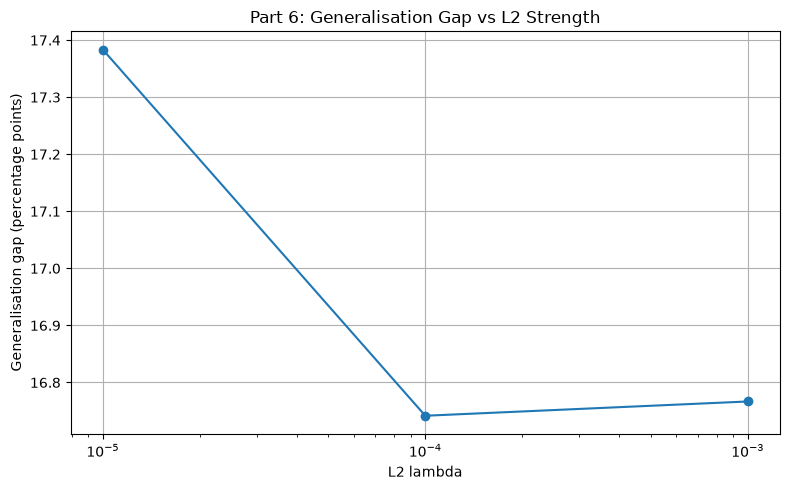

In [53]:
# Required L2 graph
plt.figure(figsize=(8, 5))

plt.plot(
    list(l2_results.keys()),
    [r['gap'] for r in l2_results.values()],
    marker='o'
)

plt.xscale('log')

plt.xlabel('L2 lambda')
plt.ylabel('Generalisation gap (percentage points)')
plt.title('Part 6: Generalisation Gap vs L2 Strength')
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
# L1 Regularisation
L1_LAMBDA = 0.0001

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

l1_model = build_regularized_model(
    l1_lambda=L1_LAMBDA
)

l1_history = l1_model.fit(
    X_overfit,
    Y_overfit_oh,
    validation_data=(X_val, Y_val_oh),
    epochs=80,
    batch_size=128,
    verbose=0
)

l1_train_acc = l1_history.history['accuracy'][-1]
l1_val_acc = l1_history.history['val_accuracy'][-1]

l1_gap = (l1_train_acc - l1_val_acc) * 100

print(f"L1 lambda: {L1_LAMBDA}")
print(f"Train accuracy: {l1_train_acc*100:.2f}%")
print(f"Validation accuracy: {l1_val_acc*100:.2f}%")
print(f"Gap: {l1_gap:.2f} percentage points")

L1 lambda: 0.0001
Train accuracy: 96.60%
Validation accuracy: 80.87%
Gap: 15.73 percentage points


In [56]:
threshold = 1e-3

all_weights = []

for layer in l1_model.layers:
    weights = layer.get_weights()

    for w in weights:
        all_weights.extend(w.flatten())

all_weights = np.array(all_weights)

percentage_small = (
    np.mean(np.abs(all_weights) < threshold) * 100
)

print(
    f"Percentage of weights below 1e-3: "
    f"{percentage_small:.2f}%"
)

Percentage of weights below 1e-3: 80.18%


In [57]:
# Dropout
dropout_results = {}
dropout_histories = {}

DROPOUT_RATES = [0.2, 0.4, 0.6]

for rate in DROPOUT_RATES:

    print(f"\nTraining Dropout rate = {rate}")

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_regularized_model(
        dropout_rate=rate
    )

    history = model.fit(
        X_overfit,
        Y_overfit_oh,
        validation_data=(X_val, Y_val_oh),
        epochs=80,
        batch_size=128,
        verbose=0
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy']
    val_acc_final = val_acc[-1]

    gap = (train_acc - val_acc_final) * 100

    dropout_histories[rate] = history

    dropout_results[rate] = {
        'train_accuracy': train_acc,
        'val_accuracy': val_acc_final,
        'gap': gap
    }

    print(f"Train accuracy: {train_acc*100:.2f}%")
    print(f"Validation accuracy: {val_acc_final*100:.2f}%")
    print(f"Gap: {gap:.2f} percentage points")


Training Dropout rate = 0.2
Train accuracy: 97.80%
Validation accuracy: 82.96%
Gap: 14.84 percentage points

Training Dropout rate = 0.4
Train accuracy: 93.05%
Validation accuracy: 83.44%
Gap: 9.61 percentage points

Training Dropout rate = 0.6
Train accuracy: 87.30%
Validation accuracy: 82.61%
Gap: 4.69 percentage points


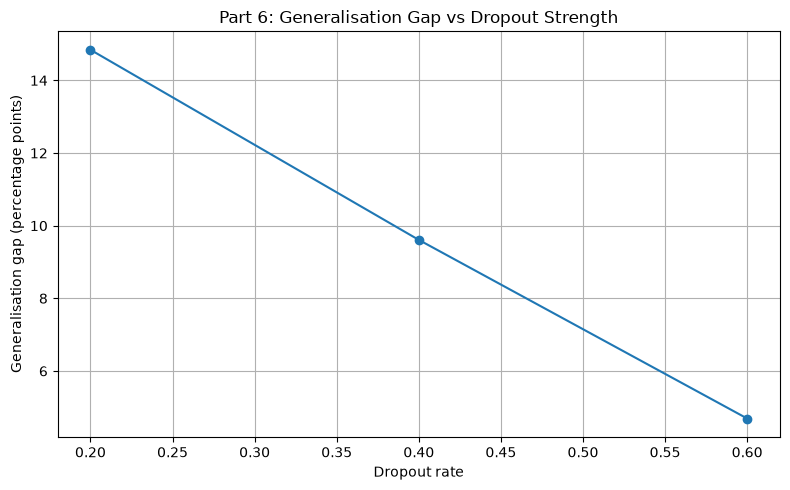

In [58]:
plt.figure(figsize=(8, 5))

rates = list(dropout_results.keys())
gaps = [dropout_results[r]['gap'] for r in rates]

plt.plot(rates, gaps, marker='o')

plt.xlabel('Dropout rate')
plt.ylabel('Generalisation gap (percentage points)')
plt.title('Part 6: Generalisation Gap vs Dropout Strength')
plt.grid(True)
plt.tight_layout()
plt.show()

Dropout reduced the generalisation gap as its rate increased. However, the 0.6 rate also reduced training accuracy considerably, so 0.4 provides a better balance between reducing overfitting and maintaining model performance.

In [59]:
# Batch Normalisation
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

bn_model = build_regularized_model(
    use_batch_norm=True
)

bn_history = bn_model.fit(
    X_overfit,
    Y_overfit_oh,
    validation_data=(X_val, Y_val_oh),
    epochs=80,
    batch_size=128,
    verbose=0
)

bn_train_acc = bn_history.history['accuracy'][-1]
bn_val_acc = bn_history.history['val_accuracy'][-1]

bn_gap = (bn_train_acc - bn_val_acc) * 100

print(f"Batch Normalisation")
print(f"Train accuracy: {bn_train_acc*100:.2f}%")
print(f"Validation accuracy: {bn_val_acc*100:.2f}%")
print(f"Gap: {bn_gap:.2f} percentage points")

Batch Normalisation
Train accuracy: 100.00%
Validation accuracy: 83.68%
Gap: 16.32 percentage points


In [60]:
# Early Stopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

early_model = build_regularized_model()

early_history = early_model.fit(
    X_overfit,
    Y_overfit_oh,
    validation_data=(X_val, Y_val_oh),
    epochs=80,
    batch_size=128,
    callbacks=[early_stop],
    verbose=0
)

es_train_acc = early_history.history['accuracy'][-1]
es_val_acc = early_history.history['val_accuracy'][-1]
es_gap = (es_train_acc - es_val_acc) * 100

stopped_epoch = len(early_history.history['loss'])

print(f"Patience: 5")
print(f"Training stopped at epoch: {stopped_epoch}")
print(f"Train accuracy: {es_train_acc*100:.2f}%")
print(f"Validation accuracy: {es_val_acc*100:.2f}%")
print(f"Gap: {es_gap:.2f} percentage points")

Patience: 5
Training stopped at epoch: 10
Train accuracy: 91.70%
Validation accuracy: 81.39%
Gap: 10.31 percentage points


Early stopping reduced the generalisation gap from 16.81 pp → 10.31 pp, but it also reduced the training accuracy because the model stopped before it could fully fit the 2,000 samples. That's expected—the purpose is to stop training before the model starts strongly overfitting.

In [61]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05)
])

def build_augmented_model():

    inputs = tf.keras.Input(shape=(784,))

    # Flattened 784 → image 28x28x1
    x = tf.keras.layers.Reshape((28, 28, 1))(inputs)

    # Apply augmentation during training
    x = data_augmentation(x)

    # Flatten back to 784
    x = tf.keras.layers.Flatten()(x)

    x = Dense(512, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    x = Dense(512, activation='relu')(x)

    outputs = Dense(10, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [62]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

aug_model = build_augmented_model()

aug_history = aug_model.fit(
    X_overfit,
    Y_overfit_oh,
    validation_data=(X_val, Y_val_oh),
    epochs=80,
    batch_size=128,
    verbose=0
)

aug_train_acc = aug_history.history['accuracy'][-1]
aug_val_acc = aug_history.history['val_accuracy'][-1]

aug_gap = (aug_train_acc - aug_val_acc) * 100

print("Data Augmentation")
print(f"Train accuracy: {aug_train_acc*100:.2f}%")
print(f"Validation accuracy: {aug_val_acc*100:.2f}%")
print(f"Gap: {aug_gap:.2f} percentage points")

Data Augmentation
Train accuracy: 94.20%
Validation accuracy: 81.04%
Gap: 13.16 percentage points


In [63]:
# More Training Data: 10,000 and 20,000 samples

more_data_results = {}

for n_samples in [10000, 20000]:

    print(f"\nTraining with {n_samples} samples")

    X_more = X_train[:n_samples]
    Y_more = Y_train_oh[:n_samples]

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_regularized_model()

    history = model.fit(
        X_more,
        Y_more,
        validation_data=(X_val, Y_val_oh),
        epochs=80,
        batch_size=128,
        verbose=0
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    gap = (train_acc - val_acc) * 100

    more_data_results[n_samples] = {
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'gap': gap
    }

    print(f"Train accuracy: {train_acc*100:.2f}%")
    print(f"Validation accuracy: {val_acc*100:.2f}%")
    print(f"Gap: {gap:.2f} percentage points")


Training with 10000 samples
Train accuracy: 98.29%
Validation accuracy: 86.50%
Gap: 11.79 percentage points

Training with 20000 samples
Train accuracy: 98.49%
Validation accuracy: 86.83%
Gap: 11.66 percentage points


# Part 7 : Hyperparameter Tuning

In [73]:
def build_tuning_model(
    learning_rate=0.001,
    hidden_width=256,
    dropout_rate=0.4
):
    model = Sequential([
        tf.keras.Input(shape=(784,)),

        Dense(hidden_width, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),

        Dense(hidden_width, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),

        Dense(hidden_width, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),

        Dense(hidden_width, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [74]:
# Define the search space
from sklearn.model_selection import ParameterSampler, StratifiedKFold
search_space = {
    'learning_rate': [0.0005, 0.001, 0.002],
    'hidden_width': [128, 256, 512],
    'dropout_rate': [0.2, 0.4, 0.6]
}
random_configs = list(
    ParameterSampler(
        search_space,
        n_iter=12,
        random_state=SEED
    )
)

print("Number of configurations:", len(random_configs))

for i, config in enumerate(random_configs, 1):
    print(f"{i}: {config}")

Number of configurations: 12
1: {'learning_rate': 0.002, 'hidden_width': 512, 'dropout_rate': 0.2}
2: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.4}
3: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.4}
4: {'learning_rate': 0.0005, 'hidden_width': 256, 'dropout_rate': 0.6}
5: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.2}
6: {'learning_rate': 0.002, 'hidden_width': 128, 'dropout_rate': 0.4}
7: {'learning_rate': 0.001, 'hidden_width': 512, 'dropout_rate': 0.4}
8: {'learning_rate': 0.002, 'hidden_width': 512, 'dropout_rate': 0.4}
9: {'learning_rate': 0.0005, 'hidden_width': 256, 'dropout_rate': 0.4}
10: {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.6}
11: {'learning_rate': 0.001, 'hidden_width': 128, 'dropout_rate': 0.2}
12: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.2}


In [75]:
Y_train = np.argmax(Y_train_oh, axis=1)

In [77]:
# 5-fold Cross-Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)
cv_results = []

for config_number, config in enumerate(random_configs, 1):

    print(
        f"\nConfiguration {config_number}/12: "
        f"{config}"
    )

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_train, Y_train), 1
    ):

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED + fold)

        model = build_tuning_model(
            learning_rate=config['learning_rate'],
            hidden_width=config['hidden_width'],
            dropout_rate=config['dropout_rate']
        )

        history = model.fit(
            X_train[train_idx],
            Y_train_oh[train_idx],
            validation_data=(
                X_train[val_idx],
                Y_train_oh[val_idx]
            ),
            epochs=20,
            batch_size=128,
            verbose=0
        )

        # Best validation accuracy within this fold
        best_fold_accuracy = max(
            history.history['val_accuracy']
        )

        fold_scores.append(best_fold_accuracy)

        print(
            f"  Fold {fold}: "
            f"{best_fold_accuracy:.4f}"
        )

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)

    cv_results.append({
        'config': config_number,
        'learning_rate': config['learning_rate'],
        'hidden_width': config['hidden_width'],
        'dropout_rate': config['dropout_rate'],
        'mean_cv_accuracy': mean_score,
        'std_cv_accuracy': std_score
    })

    print(
        f"  Mean CV accuracy: {mean_score:.4f}"
    )
    print(
        f"  Std CV accuracy: {std_score:.4f}"
    )


Configuration 1/12: {'learning_rate': 0.002, 'hidden_width': 512, 'dropout_rate': 0.2}
  Fold 1: 0.8856
  Fold 2: 0.8867
  Fold 3: 0.8867
  Fold 4: 0.8827
  Fold 5: 0.8865
  Mean CV accuracy: 0.8856
  Std CV accuracy: 0.0015

Configuration 2/12: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.4}
  Fold 1: 0.8844
  Fold 2: 0.8830
  Fold 3: 0.8809
  Fold 4: 0.8785
  Fold 5: 0.8828
  Mean CV accuracy: 0.8819
  Std CV accuracy: 0.0020

Configuration 3/12: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.4}
  Fold 1: 0.8795
  Fold 2: 0.8777
  Fold 3: 0.8794
  Fold 4: 0.8745
  Fold 5: 0.8766
  Mean CV accuracy: 0.8775
  Std CV accuracy: 0.0019

Configuration 4/12: {'learning_rate': 0.0005, 'hidden_width': 256, 'dropout_rate': 0.6}
  Fold 1: 0.8682
  Fold 2: 0.8658
  Fold 3: 0.8660
  Fold 4: 0.8567
  Fold 5: 0.8668
  Mean CV accuracy: 0.8647
  Std CV accuracy: 0.0041

Configuration 5/12: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.2}
  Fol

In [79]:
cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    'mean_cv_accuracy',
    ascending=False
).reset_index(drop=True)

display(cv_df)

,config,learning_rate,hidden_width,dropout_rate,mean_cv_accuracy,std_cv_accuracy
0,12,0.0010,256,0.2,0.889000,0.002313
1,9,0.0005,256,0.4,0.886979,0.001869
2,5,0.0005,128,0.2,0.886979,0.001843
3,1,0.0020,512,0.2,0.885625,0.001508
4,11,0.0010,128,0.2,0.884917,0.002722
5,7,0.0010,512,0.4,0.884208,0.001117
6,2,0.0010,256,0.4,0.881937,0.002021
7,3,0.0005,128,0.4,0.877521,0.001870
8,10,0.0005,512,0.6,0.876604,0.002749
9,8,0.0020,512,0.4,0.871562,0.002873


In [80]:
top5_cv = cv_df.head(5)
display(top5_cv)

,config,learning_rate,hidden_width,dropout_rate,mean_cv_accuracy,std_cv_accuracy
0,12,0.0010,256,0.2,0.889000,0.002313
1,9,0.0005,256,0.4,0.886979,0.001869
2,5,0.0005,128,0.2,0.886979,0.001843
3,1,0.0020,512,0.2,0.885625,0.001508
4,11,0.0010,128,0.2,0.884917,0.002722


In [81]:
# Final selected model

best_lr = 0.001
best_width = 256
best_dropout = 0.2

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

final_model = build_tuning_model(
    learning_rate=best_lr,
    hidden_width=best_width,
    dropout_rate=best_dropout
)

final_history = final_model.fit(
    X_train,
    Y_train_oh,
    validation_data=(X_val, Y_val_oh),
    epochs=30,
    batch_size=128,
    verbose=1
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7661 - loss: 0.6440 - val_accuracy: 0.8241 - val_loss: 0.4466
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8416 - loss: 0.4381 - val_accuracy: 0.8420 - val_loss: 0.4117
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8570 - loss: 0.3952 - val_accuracy: 0.8575 - val_loss: 0.3872
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8674 - loss: 0.3683 - val_accuracy: 0.8682 - val_loss: 0.3624
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8706 - loss: 0.3597 - val_accuracy: 0.8727 - val_loss: 0.3479
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8767 - loss: 0.3423 - val_accuracy: 0.8717 - val_loss: 0.3514
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8798 - loss: 0.3314 - val_accuracy: 0.8765 - val_loss: 0.3399
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8827 - loss: 0.3222 - val_accu

In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt

# Final evaluation on untouched test set
Y_test_pred_prob = final_model.predict(X_test, verbose=0)

Y_test_pred = np.argmax(Y_test_pred_prob, axis=1)
Y_test_true = np.argmax(Y_test_oh, axis=1)

test_accuracy = accuracy_score(Y_test_true, Y_test_pred)

test_precision = precision_score(
    Y_test_true,
    Y_test_pred,
    average='macro'
)

test_recall = recall_score(
    Y_test_true,
    Y_test_pred,
    average='macro'
)

test_f1 = f1_score(
    Y_test_true,
    Y_test_pred,
    average='macro'
)

print("FINAL TEST RESULTS")
print("===================")
print(f"Test Accuracy:   {test_accuracy*100:.2f}%")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1:        {test_f1:.4f}")

FINAL TEST RESULTS
Test Accuracy:   89.57%
Macro Precision: 0.8959
Macro Recall:    0.8957
Macro F1:        0.8953


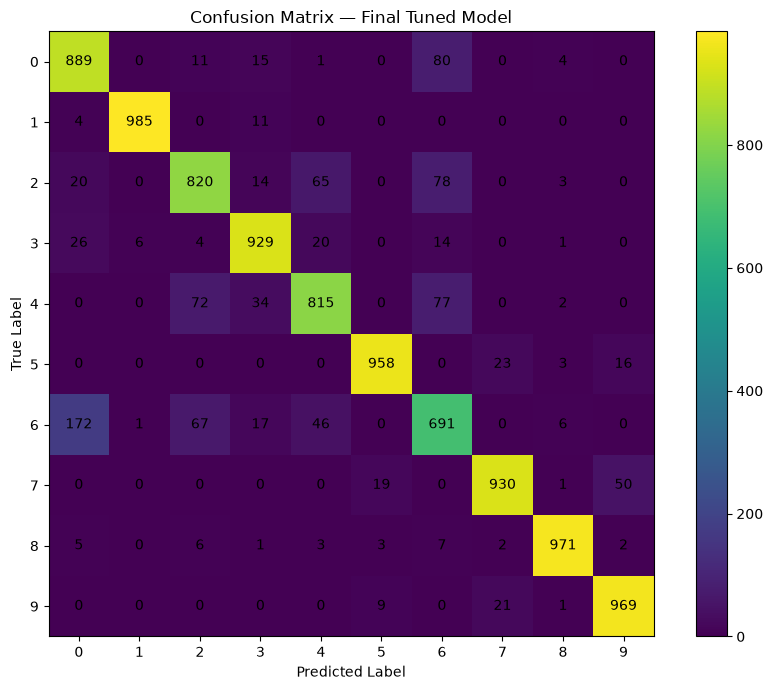

In [84]:
cm = confusion_matrix(Y_test_true, Y_test_pred)

plt.figure(figsize=(9, 7))

plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix — Final Tuned Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.colorbar()

classes = np.arange(10)

plt.xticks(classes, classes)
plt.yticks(classes, classes)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()